In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy import constants as const, units as u
import copy

import pyFLD as fld

In [2]:
# In previous problems we assumed a fixed density structure. Here we'll account for
# changes in the temperature profile by re-calculating the density profile, and iterate
# between temperature and density updates. Note that dust must account for settling!

# For this problem we'll also only consider the top half of the disk for simplicity,
# and ignore the rim. We therefore will need to provide a (simple) formula for the optical depth
# between the rim and the start of our domain. We'll use the one from Flock+2019.

d2g = 1e-3 # dust-to-gas ratio

# === grid and star ===
star = fld.star.Star(M=1*u.M_sun, L=1*u.L_sun)
ri   = fld.grid.get_domain_with_ghosts(0.1, 10, Nx=128, log=True) * u.au
thi  = fld.grid.get_domain_with_ghosts(np.pi/2-0.3, np.pi/2, Nx=512)
phii = fld.grid.get_domain_with_ghosts(0, 2*np.pi, Nx=1)
grid = fld.grid.Grid(ri, thi, phii, geometry='spherical')

# === initialization of objects ===
Gas = fld.fluids.Gas(grid=grid, star=star, irradiation='gray', debug=False, name='basic')
Dust = fld.fluids.Dust(grid=grid, star=star, irradiation='gray', debug=False, name='basic',
                       grain_rho=2.08*u.g/u.cm**3, grain_size=1*u.um)

# === density and temperature ===
R_ = grid.R.to_value('au')
z_ = grid.z.to_value('au')
H_ = 0.03 * R_ ** 1.25
rho = 3e-10 * u.g/u.cm**3 * R_ ** -1.5 * np.exp(-0.5*(z_/H_)**2)

Gas.set_density(np.ones(grid.shape) * rho)
Dust.set_density(np.ones(grid.shape) * rho * d2g)
Gas.set_temperature(np.ones(grid.shape) * 140 * u.K * R_ ** -0.45) # starting guess from notebook 1
Dust.set_temperature(np.ones(grid.shape) * 140 * u.K * R_ ** -0.45) # same starting guess

# === opacities and optical depth ===
# low gas opacity
Gas.enroll_kappaR(lambda f: 1e-3 * u.cm**2/u.g)
Gas.enroll_kappaP(lambda f: 1e0 * u.cm**2/u.g)
Gas.enroll_kappaPstar(lambda f: 1e0 * u.cm**2/u.g)
# optool dust opacity for 0.1 um grains from Ziampras+2025
Dust.enroll_kappaR(lambda f: f.tmp.to_value('K')**1.6 * 0.27 * u.cm**2/u.g)
Dust.enroll_kappaP(lambda f: f.tmp.to_value('K')**1.6 * 0.41 * u.cm**2/u.g)
Dust.enroll_kappaPstar(lambda f: f.star.T.to_value('K')**1.6 * 0.41 * u.cm**2/u.g)

# τ0 = (ρκ)_{r_in) * (r_in - 3*R_star) from Flock+ (2019)
def get_tau0(fluid): return (fluid.rho * fluid.kappaPstar * (grid.R-3*star.R))[:, :, grid.ibeg]

# inform the fluids
Gas.enroll_tau0(get_tau0) # you can also just pass fld.tools.get_tau0_Flock_2019 here
Dust.enroll_tau0(get_tau0) # and here

# since we need to account for dust settling, we need a vertical turbulence parameter
Dust.enroll_alpha(lambda f: 1e-1)

# === setup ===
Gas.setup()
Dust.setup()

Disk = fld.FLD.RadiativeEnvironment([Gas, Dust], verbose=True, debug=False, name='disk')

# === boundary conditions ===
# for this problem we simplify a bit by only simulating half the disk -> the x2 domain extends to π/2 and is reflective there
bounds, vals = [fld.grid.BOUNDARY_FIXEDVALUE] * 6, [fld.tools.T_to_Er(10*u.K)] * 6
vals[0] = fld.tools.T_to_Er(400*u.K)
vals[1] = fld.tools.T_to_Er(50*u.K)
bounds[3] = fld.grid.BOUNDARY_REFLECTIVE # the value doesn't matter
Disk.declare_boundaries(bounds, vals)

In [3]:
# run the model
for _ in range(30): Disk.advance(dt=1e10 * u.yr)

RadiativeEnvironment 'disk': Converged in 6 iterations.
RadiativeEnvironment 'disk': Converged in 11 iterations.
RadiativeEnvironment 'disk': Converged in 10 iterations.
RadiativeEnvironment 'disk': Converged in 10 iterations.
RadiativeEnvironment 'disk': Converged in 9 iterations.
RadiativeEnvironment 'disk': Converged in 9 iterations.
RadiativeEnvironment 'disk': Converged in 10 iterations.
RadiativeEnvironment 'disk': Converged in 9 iterations.
RadiativeEnvironment 'disk': Converged in 8 iterations.
RadiativeEnvironment 'disk': Converged in 8 iterations.
RadiativeEnvironment 'disk': Converged in 7 iterations.
RadiativeEnvironment 'disk': Converged in 8 iterations.
RadiativeEnvironment 'disk': Converged in 8 iterations.
RadiativeEnvironment 'disk': Converged in 8 iterations.
RadiativeEnvironment 'disk': Converged in 8 iterations.
RadiativeEnvironment 'disk': Converged in 8 iterations.
RadiativeEnvironment 'disk': Converged in 8 iterations.
RadiativeEnvironment 'disk': Converged in 8 

In [4]:
r = grid.x1[grid.act1].to_value('au')
theta = grid.x2[grid.act2]
phi = grid.x3[grid.act3]
mid = grid.mid

def fmt(qty3D): return 1 * qty3D[grid.active][0] # take the 0th (only) element in φ

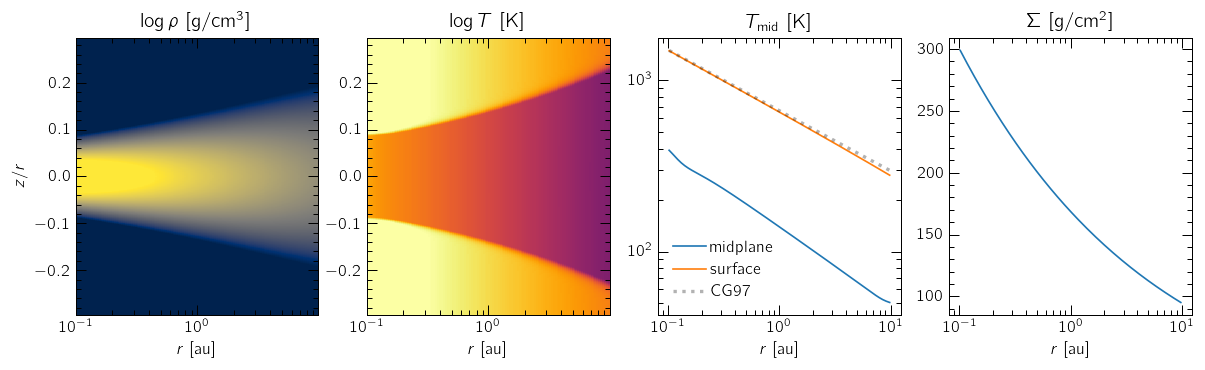

In [5]:
fig, ax = plt.subplots(ncols=4, figsize=(12, 3), dpi=120)
ax[0].pcolormesh(r, np.cos(theta), np.log10(fmt(Disk.rho).to_value('g/cm3')), cmap=plt.cm.cividis, vmin=-14, vmax=-9)
ax[0].pcolormesh(r, -np.cos(theta), np.log10(fmt(Disk.rho).to_value('g/cm3')), cmap=plt.cm.cividis, vmin=-14, vmax=-9)
ax[1].pcolormesh(r, np.cos(theta), np.log10(fmt(Disk.tmp).to_value('K')), cmap=plt.cm.inferno, vmin=1, vmax=3)
ax[1].pcolormesh(r, -np.cos(theta), np.log10(fmt(Disk.tmp).to_value('K')), cmap=plt.cm.inferno, vmin=1, vmax=3)
ax[2].plot(r, fmt(Disk.tmp).to_value('K')[mid], label='midplane')
ax[2].plot(r, fmt(Disk.tmp).to_value('K')[0], label='surface') # surface
ax[3].plot(r, (fmt(Disk.rho * grid.dz)).sum(0).to_value('g/cm2')) # surface density

for axis in ax: axis.set_xscale('log')
ax[2].set_yscale('log')

# the Chiang and Goldreich formula also includes the ratio of opacities at Tstar/Tdisk
opac_factor = fmt((Dust.kappaPstar+Gas.kappaPstar)/(Dust.kappaP+Gas.kappaP))[0] ** 0.25
TCC97 = (star.T * np.sqrt(0.5*star.R/grid.x1[grid.act1])).to_value('K') * opac_factor
ax[2].plot(r, TCC97, ls=':', c='k', alpha=0.3, lw=2, label='CG97')

ax[2].legend()

for axis in ax: axis.set_xlabel(r'$r$ [au]')
ax[0].set_ylabel(r'$z/r$')
ax[0].set_title(r'$\log\rho$ [g/cm${}^3$]')
ax[1].set_title(r'$\log T$ [K]')
ax[2].set_title(r'$T_\mathrm{mid}$ [K]')
ax[3].set_title(r'$\Sigma$ [g/cm${}^2$]')

plt.show()

In [6]:
# now compute the density profile at this steady state. This accounts for settling automatically
Disk.enforce_hydrostatic_equilibrium()

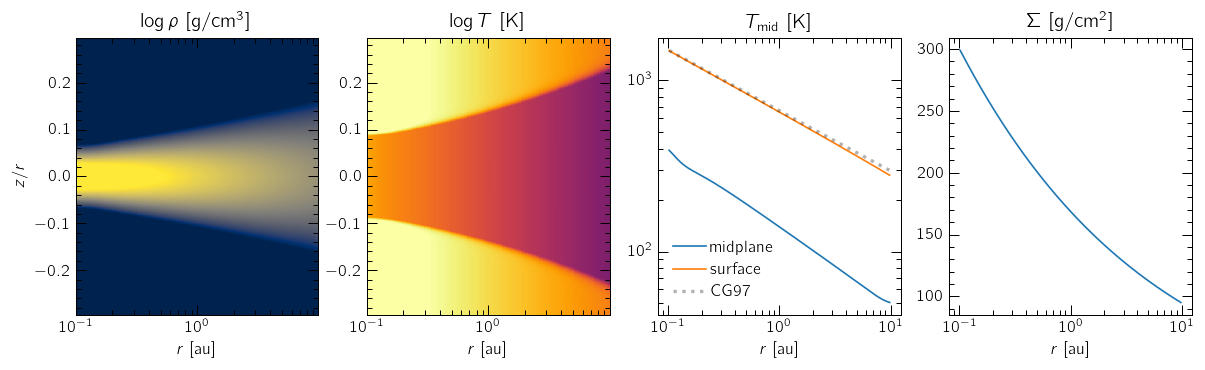

In [7]:
# and check the output
fig, ax = plt.subplots(ncols=4, figsize=(12, 3), dpi=120)
ax[0].pcolormesh(r, np.cos(theta), np.log10(fmt(Disk.rho).to_value('g/cm3')), cmap=plt.cm.cividis, vmin=-14, vmax=-9)
ax[0].pcolormesh(r, -np.cos(theta), np.log10(fmt(Disk.rho).to_value('g/cm3')), cmap=plt.cm.cividis, vmin=-14, vmax=-9)
ax[1].pcolormesh(r, np.cos(theta), np.log10(fmt(Disk.tmp).to_value('K')), cmap=plt.cm.inferno, vmin=1, vmax=3)
ax[1].pcolormesh(r, -np.cos(theta), np.log10(fmt(Disk.tmp).to_value('K')), cmap=plt.cm.inferno, vmin=1, vmax=3)
ax[2].plot(r, fmt(Disk.tmp).to_value('K')[mid], label='midplane')
ax[2].plot(r, fmt(Disk.tmp).to_value('K')[0], label='surface') # surface
ax[3].plot(r, (fmt(Disk.rho * grid.dz)).sum(0).to_value('g/cm2')) # surface density

for axis in ax: axis.set_xscale('log')
ax[2].set_yscale('log')

# the Chiang and Goldreich formula also includes the ratio of opacities at Tstar/Tdisk
opac_factor = fmt(Dust.kappaPstar/Dust.kappaP)[0] ** 0.25
TCC97 = (star.T * np.sqrt(0.5*star.R/grid.x1[grid.act1])).to_value('K') * opac_factor
ax[2].plot(r, TCC97, ls=':', c='k', alpha=0.3, lw=2, label='CG97')

ax[2].legend()

for axis in ax: axis.set_xlabel(r'$r$ [au]')
ax[0].set_ylabel(r'$z/r$')
ax[0].set_title(r'$\log\rho$ [g/cm${}^3$]')
ax[1].set_title(r'$\log T$ [K]')
ax[2].set_title(r'$T_\mathrm{mid}$ [K]')
ax[3].set_title(r'$\Sigma$ [g/cm${}^2$]')

plt.show()

In [8]:
# run the model again, alternating between temperature and density updates
Disk.verbose = False
for i in range(10):
    for _ in range(10): Disk.advance(dt=1e3 * u.yr)
    Disk.enforce_hydrostatic_equilibrium()
    print(f'finished sypercycle {i}')

finished sypercycle 0
finished sypercycle 1
finished sypercycle 2
finished sypercycle 3
finished sypercycle 4
finished sypercycle 5
finished sypercycle 6
finished sypercycle 7
finished sypercycle 8
finished sypercycle 9


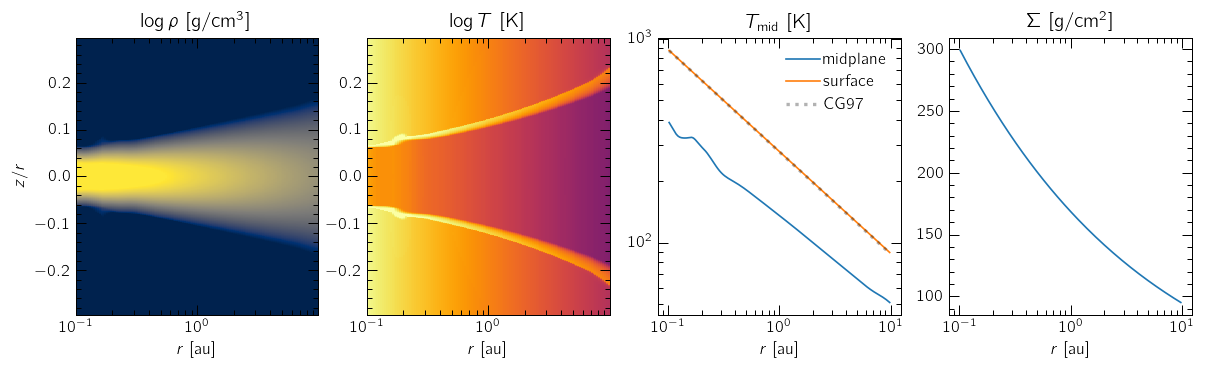

In [9]:
# and check the output again
fig, ax = plt.subplots(ncols=4, figsize=(12, 3), dpi=120)
ax[0].pcolormesh(r, np.cos(theta), np.log10(fmt(Disk.rho).to_value('g/cm3')), cmap=plt.cm.cividis, vmin=-14, vmax=-9)
ax[0].pcolormesh(r, -np.cos(theta), np.log10(fmt(Disk.rho).to_value('g/cm3')), cmap=plt.cm.cividis, vmin=-14, vmax=-9)
ax[1].pcolormesh(r, np.cos(theta), np.log10(fmt(Disk.tmp).to_value('K')), cmap=plt.cm.inferno, vmin=1, vmax=3)
ax[1].pcolormesh(r, -np.cos(theta), np.log10(fmt(Disk.tmp).to_value('K')), cmap=plt.cm.inferno, vmin=1, vmax=3)
ax[2].plot(r, fmt(Disk.tmp).to_value('K')[mid], label='midplane')
ax[2].plot(r, fmt(Disk.tmp).to_value('K')[0], label='surface') # surface
ax[3].plot(r, (fmt(Disk.rho * grid.dz)).sum(0).to_value('g/cm2')) # surface density

for axis in ax: axis.set_xscale('log')
ax[2].set_yscale('log')

# there's only gas at the optically thin layers
opac_factor = (Gas.kappaPstar/Gas.kappaP) ** 0.25
TCC97 = (star.T * np.sqrt(0.5*star.R/grid.x1[grid.act1])).to_value('K') * opac_factor
ax[2].plot(r, TCC97, ls=':', c='k', alpha=0.3, lw=2, label='CG97')

ax[2].legend()

for axis in ax: axis.set_xlabel(r'$r$ [au]')
ax[0].set_ylabel(r'$z/r$')
ax[0].set_title(r'$\log\rho$ [g/cm${}^3$]')
ax[1].set_title(r'$\log T$ [K]')
ax[2].set_title(r'$T_\mathrm{mid}$ [K]')
ax[3].set_title(r'$\Sigma$ [g/cm${}^2$]')

plt.show()

In [10]:
# note the superheated dust layer at the disk surface, and the emergence of thermal waves
# due to our iterating between density and temperature evolution over very long timescales.
# In example 4 we'll see how this hot layer can be mellowed out with frequency-dependent irradiation,
# as the latter spreads the optical surface over several layers.